In [1]:
print("Notebook working")

Notebook working


In [2]:
import scanpy as sc

# Load PBMC 3k dataset (immune cells)
adata = sc.datasets.pbmc3k()

print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [3]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [5]:
sc.pp.highly_variable_genes(adata)

In [6]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)

C:\Users\JUSTIN JAMES EGAHI\anaconda3\envs\scrna\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


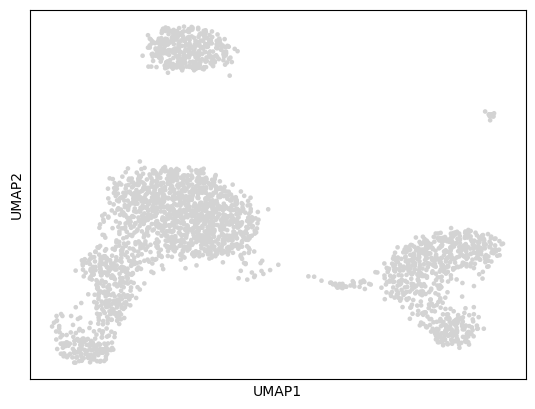

In [7]:
sc.tl.umap(adata)
sc.pl.umap(adata)

In [1]:
sc.tl.leiden(adata)

NameError: name 'sc' is not defined

In [2]:
print("still running")

still running


In [3]:
import scanpy as sc

In [4]:
print(adata)

NameError: name 'adata' is not defined

In [5]:
import scanpy as sc

In [6]:
adata= sc.datasets.pbmc3k ()
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [7]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [8]:
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)

C:\Users\JUSTIN JAMES EGAHI\anaconda3\envs\scrna\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


C:\Users\JUSTIN JAMES EGAHI\AppData\Local\Temp\ipykernel_5588\1183710404.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


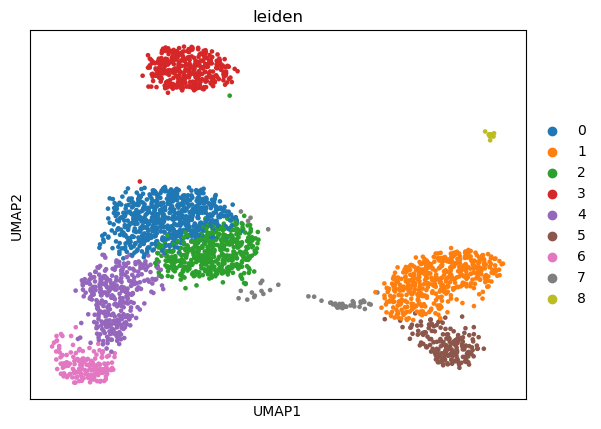

In [9]:
sc.tl.umap(adata)
sc.tl.leiden(adata)

sc.pl.umap(adata, color="leiden")

In [10]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

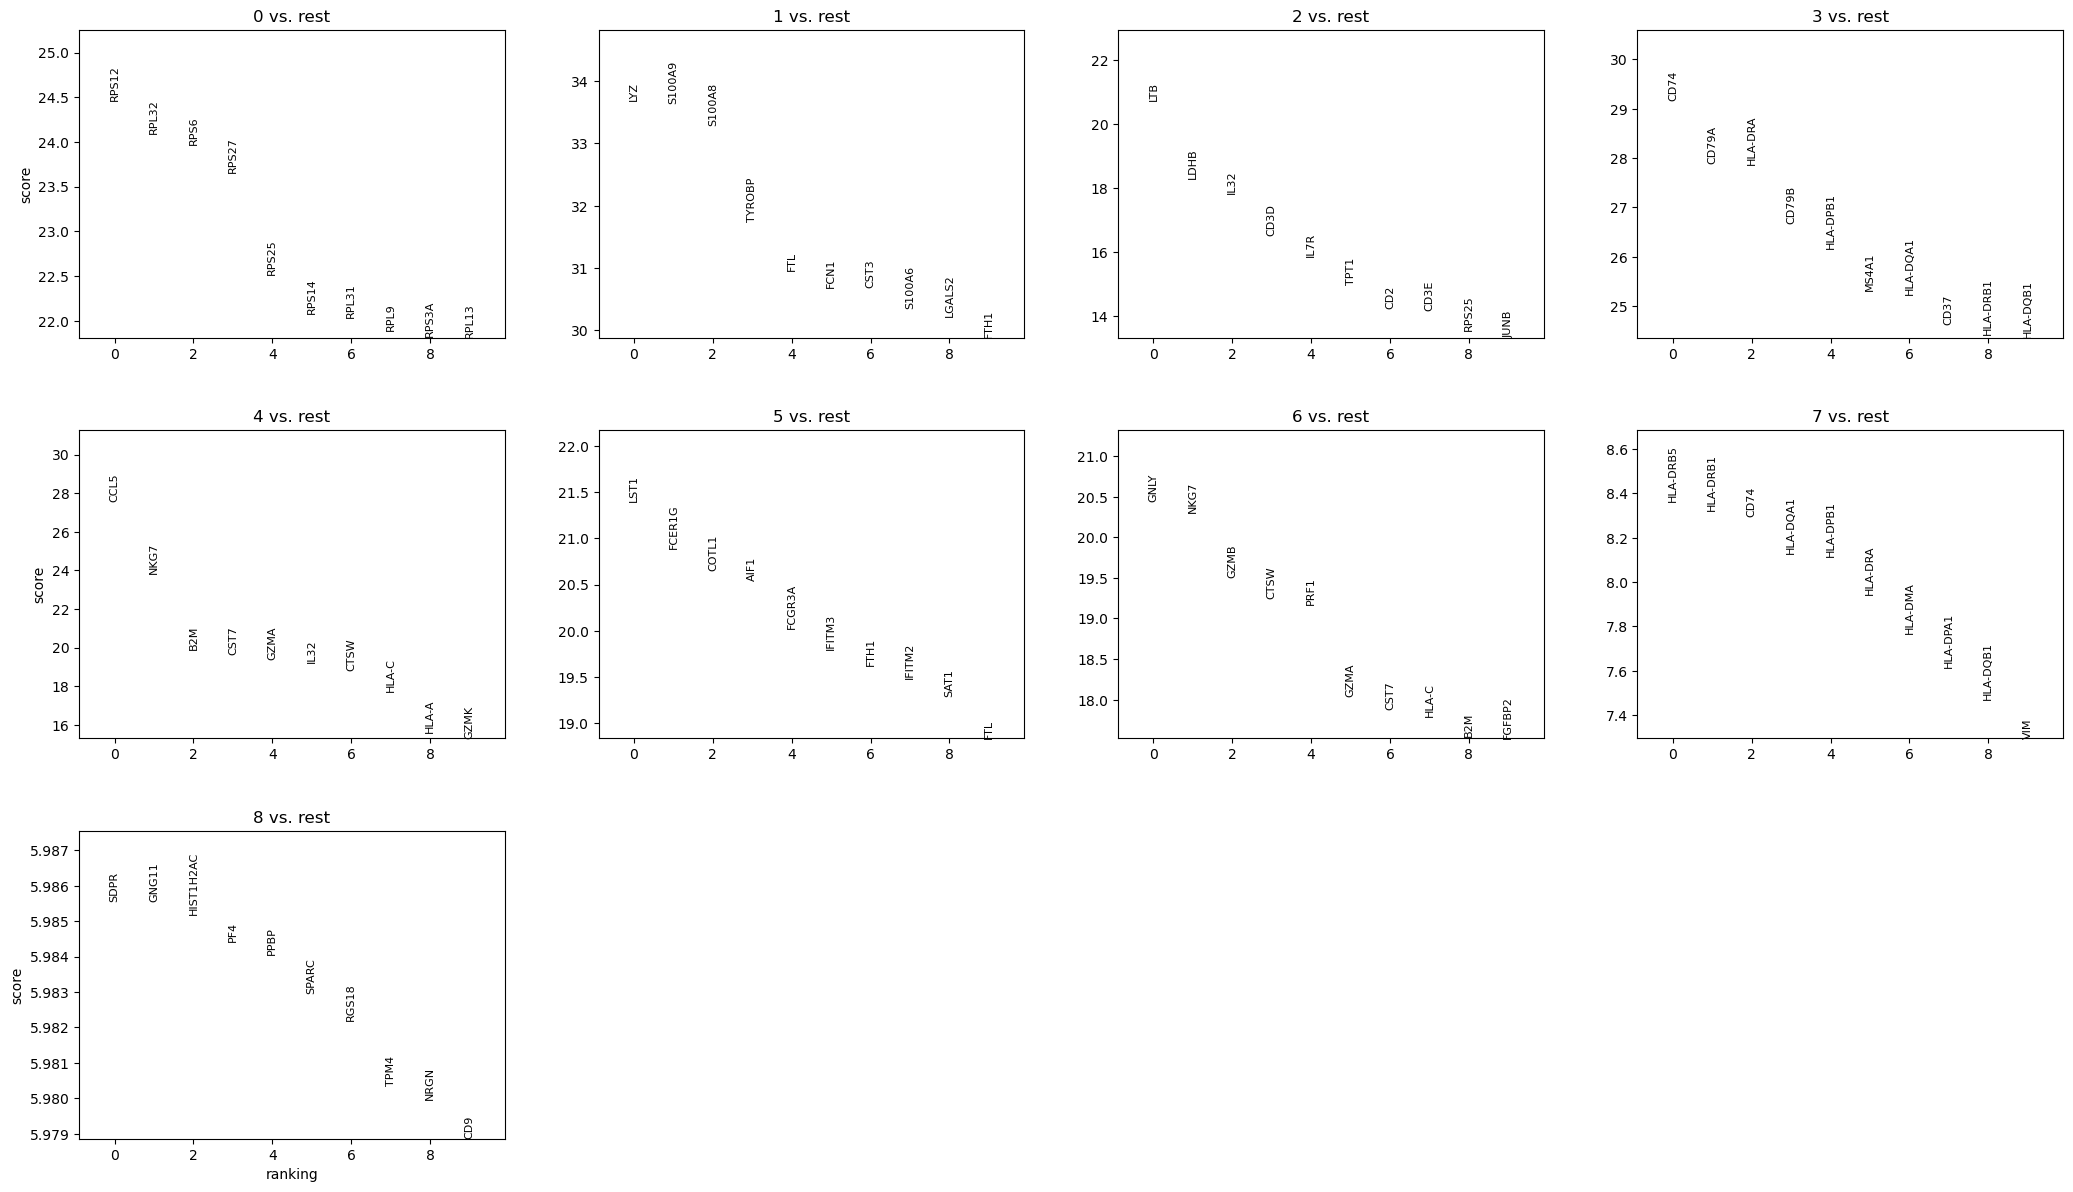

In [11]:
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [12]:
import pandas as pd

result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

marker_df = pd.DataFrame(
    {group: result['names'][group] for group in groups}
)

marker_df.head()

,0,1,2,3,4,5,6,7,8
0,RPS12,LYZ,LTB,CD74,CCL5,LST1,GNLY,HLA-DRB5,SDPR
1,RPL32,S100A9,LDHB,CD79A,NKG7,FCER1G,NKG7,HLA-DRB1,GNG11
2,RPS6,S100A8,IL32,HLA-DRA,B2M,COTL1,GZMB,CD74,HIST1H2AC
3,RPS27,TYROBP,CD3D,CD79B,CST7,AIF1,CTSW,HLA-DQA1,PF4
4,RPS25,FTL,IL7R,HLA-DPB1,GZMA,FCGR3A,PRF1,HLA-DPB1,PPBP


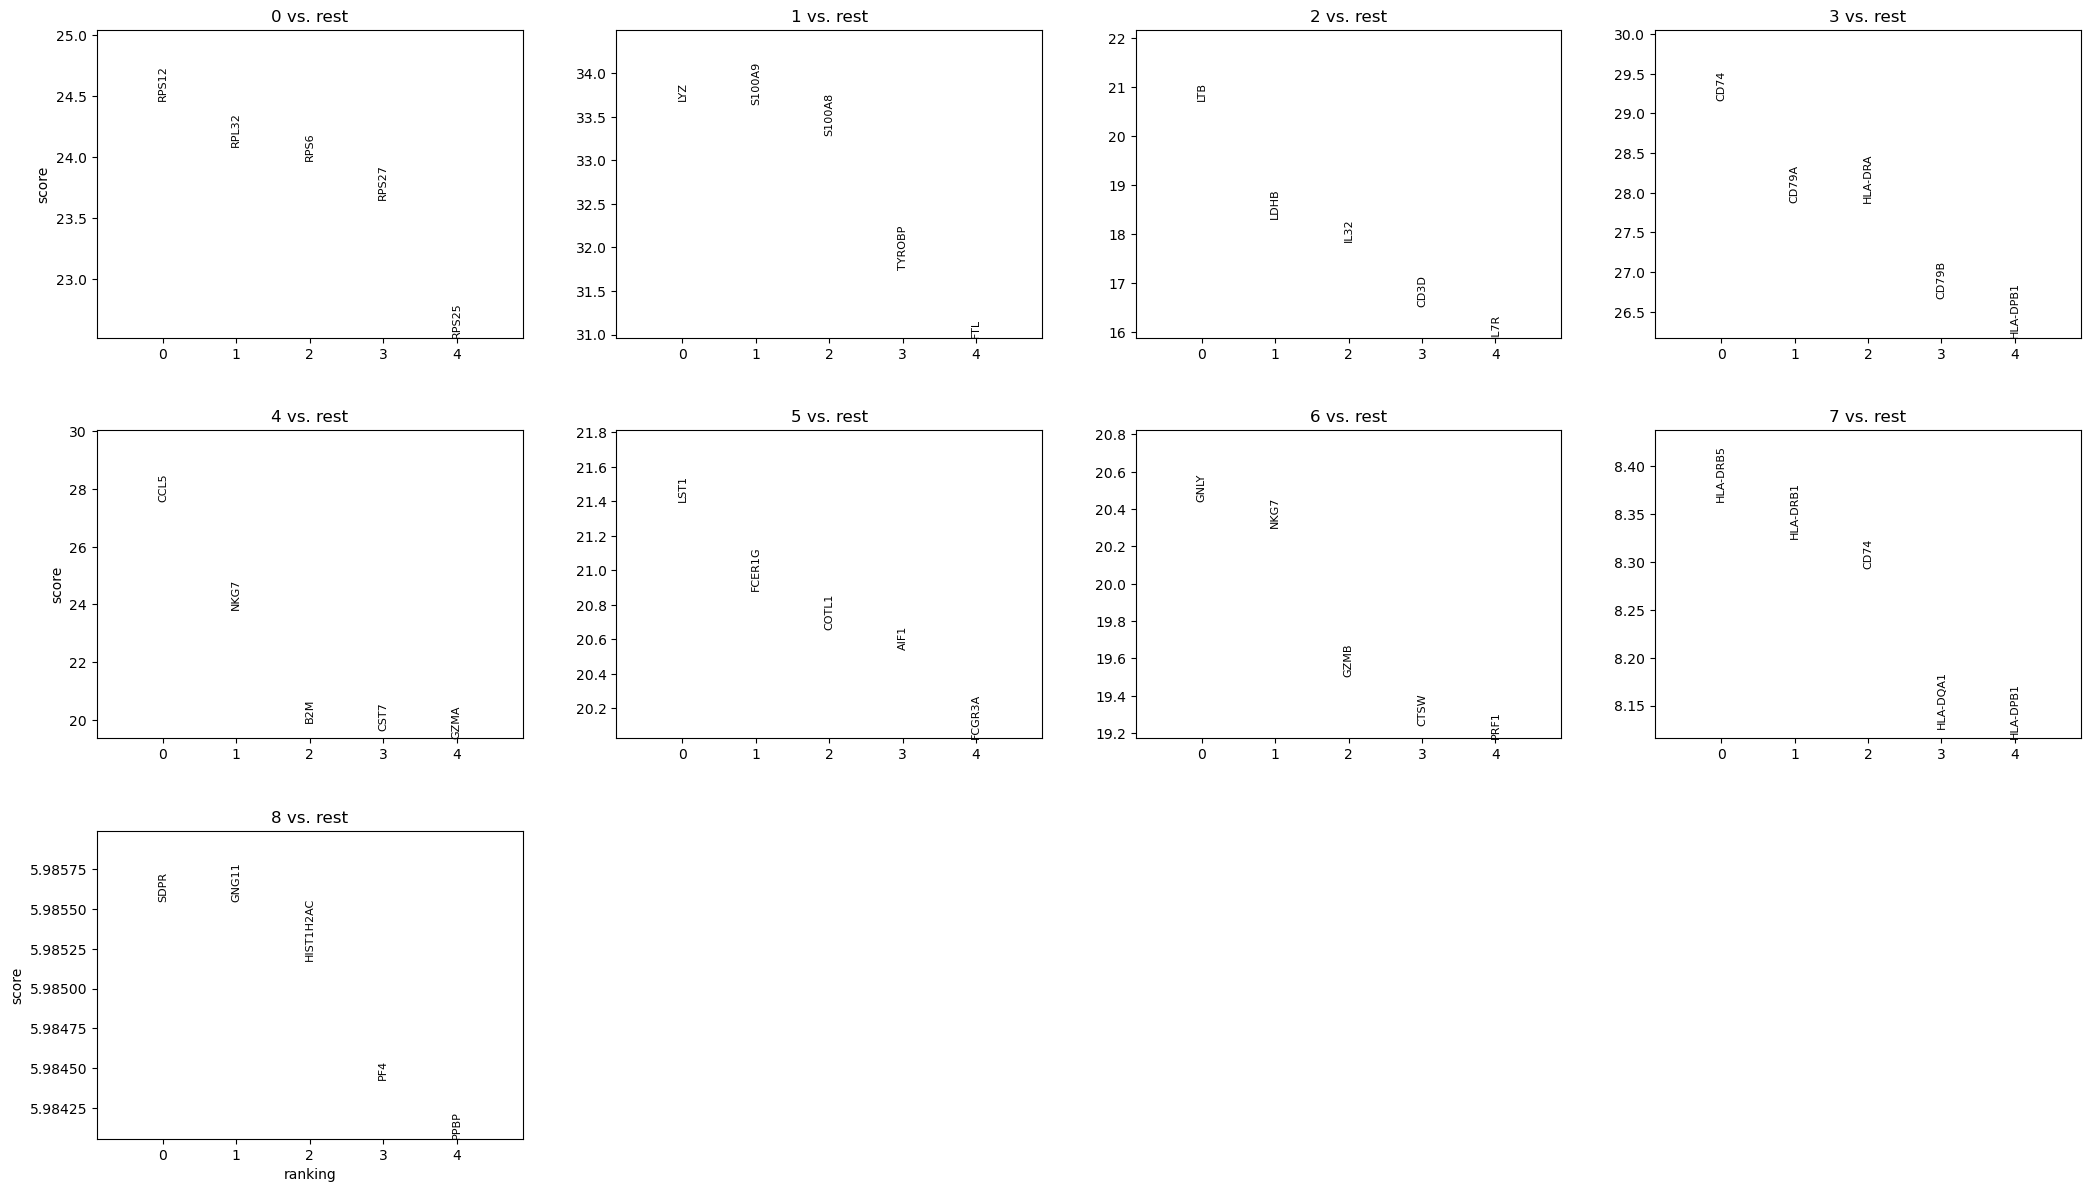

In [13]:
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

In [14]:
adata.obs["cell_type"] = adata.obs["leiden"]

In [15]:
cell_map = {
    "0": "T cells",
    "1": "Monocytes",
    "2": "B cells",
    "3": "NK cells"
}

adata.obs["cell_type"] = adata.obs["cell_type"].map(cell_map)

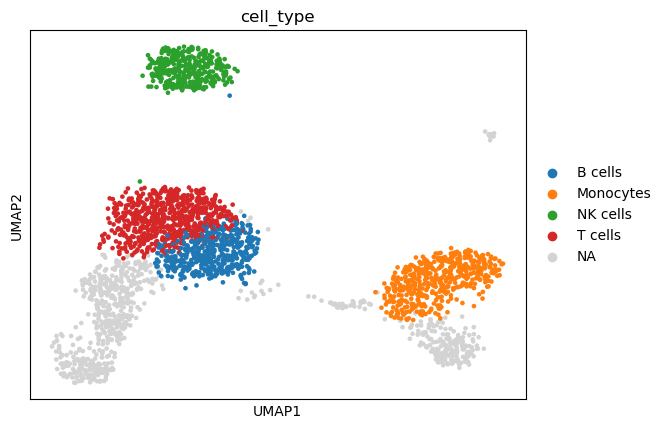

In [16]:
sc.pl.umap(adata, color="cell_type")

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [18]:
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
y = adata.obs["cell_type"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [20]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

ValueError: Input contains NaN

In [21]:
adata = adata[~adata.obs["cell_type"].isna()]

In [22]:
y = adata.obs["cell_type"].astype(str)

In [23]:
X = adata.X

# If sparse matrix, convert safely
if hasattr(X, "toarray"):
    X = X.toarray()

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8864406779661017
              precision    recall  f1-score   support

     B cells       0.90      0.58      0.71       139
   Monocytes       1.00      1.00      1.00       149
    NK cells       1.00      1.00      1.00        98
     T cells       0.77      0.96      0.85       204

    accuracy                           0.89       590
   macro avg       0.92      0.88      0.89       590
weighted avg       0.90      0.89      0.88       590



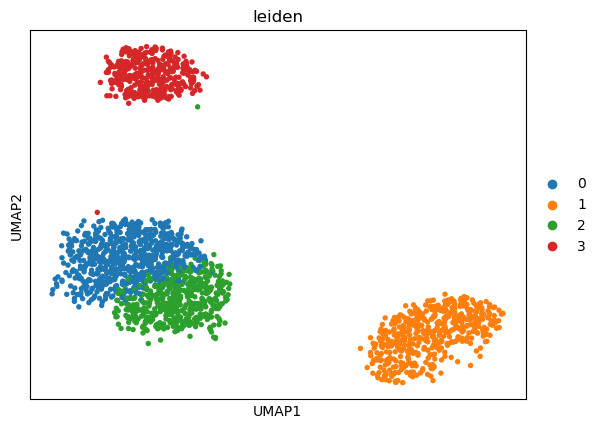

In [27]:
sc.pl.umap(adata, color="leiden", save="_umap_clusters.png")

In [28]:
import pandas as pd

result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names

df = pd.DataFrame({g: result["names"][g] for g in groups})
df.to_csv("results/markers.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'results'

In [29]:
import os

os.makedirs("results", exist_ok=True)

In [30]:
import pandas as pd

result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names

df = pd.DataFrame({g: result["names"][g] for g in groups})
df.to_csv("results/markers.csv", index=False)

In [31]:
with open("results/model_report.txt", "w") as f:
    f.write(classification_report(y_test, y_pred))

In [32]:
import os
print(os.getcwd())

C:\Users\JUSTIN JAMES EGAHI


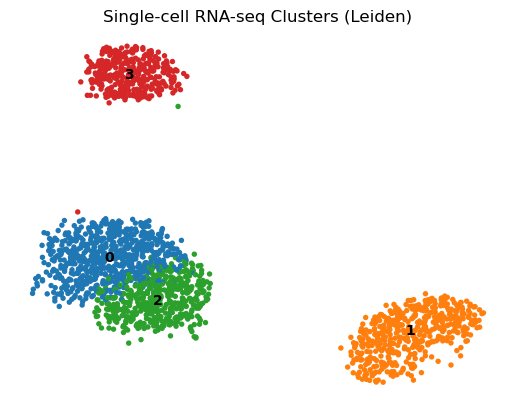

In [33]:
sc.pl.umap(
    adata,
    color="leiden",
    frameon=False,
    legend_loc="on data",
    title="Single-cell RNA-seq Clusters (Leiden)"
)

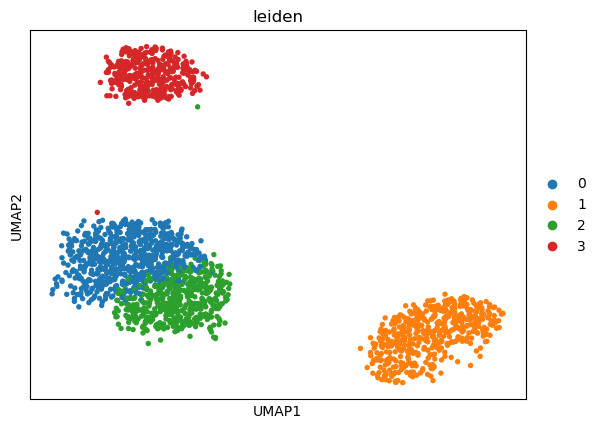

In [34]:
sc.pl.umap(
    adata,
    color="leiden",
    save="_final.png"
)

In [35]:
import pandas as pd

print("Cluster summary:")
print(adata.obs["leiden"].value_counts())

Cluster summary:
leiden
0    672
1    476
2    472
3    345
Name: count, dtype: int64
